# Prediction for possible credit defaulters

The dataset is available on [Kaggle](https://www.kaggle.com/datasets/ranadeep/credit-risk-dataset). The target dependant variable is the status of the loan of clients, denomined as 'loan_status'. 

Options are 'Fully Paid', 'Charged Off', 'Current', 'Default', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)', 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off', 'Issued'. However, we will consider only cases where a final decision has been made and the outcome regarding default is known.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Upload the dataset
bm = pd.read_csv('./loan.csv')
bm[:3] 

#Get some structural info
bm.info() 

C:\Users\rosse\AppData\Local\Temp\ipykernel_22640\2393861915.py:2: DtypeWarning: Columns (19,55) have mixed types. Specify dtype option on import or set low_memory=False.
  bm = pd.read_csv('./loan.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887379 entries, 0 to 887378
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           887379 non-null  int64  
 1   member_id                    887379 non-null  int64  
 2   loan_amnt                    887379 non-null  float64
 3   funded_amnt                  887379 non-null  float64
 4   funded_amnt_inv              887379 non-null  float64
 5   term                         887379 non-null  object 
 6   int_rate                     887379 non-null  float64
 7   installment                  887379 non-null  float64
 8   grade                        887379 non-null  object 
 9   sub_grade                    887379 non-null  object 
 10  emp_title                    835917 non-null  object 
 11  emp_length                   842554 non-null  object 
 12  home_ownership               887379 non-null  object 
 13 

Our target variable is 'loan_status'. However, we would like to remove categories such as 'Current' or 'Issued' from the target, since they don't represent a final outcome (they could still turn out to be either positive or negative), and might therefore introduce noise. We also exclude 'In Grace Period', 'Late (16-30 days)', and 'Late (31-120 days)', since these loans could still be paid off.

In [3]:
#Keep 'bm' as the untouched original dataset; all preprocessing happens on 'cm'
cm = bm.copy()

open_statuses = ['Current', 'Issued', 'In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)']
cm = cm[~cm['loan_status'].isin(open_statuses)]

#Only the definitive statuses are left
default_statuses = ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']
paid_statuses = ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid']

#A new target column is now created with a binary outcome
cm['target'] = cm['loan_status'].apply(lambda x: 1 if x in default_statuses else 0) 
print(cm['target'][:5])

#Double-check that no other options are present
cm['loan_status'].unique() 

0    0
1    1
2    0
3    0
5    0
Name: target, dtype: int64


array(['Fully Paid', 'Charged Off', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

## Select the predictor variables
We now focus our attention on selecting the variables that can be used for prediction.

For (some) categorical variables, we compute the default rate (mean of 'target') within each category, and then measure the spread (max - min) across categories. A wide spread suggests the variable is likely predictive, since the default rate varies substantially depending on the category.

In [4]:
#Total default average rate
print(cm['target'].mean())

#Comparing default rates across categorical variables
categ_vars = ['purpose', 'emp_length', 'term', 'home_ownership', 'grade', 'verification_status']

summary = {}
for col in categ_vars:
    rates = cm.groupby(col)['target'].mean()
    summary[col] = rates.max() - rates.min()

pd.Series(summary).sort_values(ascending=False)

0.1838101650586326


grade                  0.348370
home_ownership         0.212291
purpose                0.170180
term                   0.141365
verification_status    0.064796
emp_length             0.015339
dtype: float64

## About variables 'emp_length' and 'verification_status'

In [5]:
print(cm['verification_status'].isna().mean())

print(cm['emp_length'].unique())
print(cm['emp_length'].isna().mean())

cm['emp_length'] = cm['emp_length'].fillna('Missing')

rates = cm.groupby('emp_length')['target'].mean().sort_values(ascending=False)
print(rates)

0.0
['10+ years' '< 1 year' '3 years' '9 years' '4 years' '5 years' '1 year'
 '6 years' '2 years' '7 years' '8 years' nan]
0.03892752754544853
emp_length
Missing      0.261048
9 years      0.190452
7 years      0.189745
< 1 year     0.188931
8 years      0.187796
6 years      0.187233
1 year       0.182091
5 years      0.181888
3 years      0.178795
4 years      0.175917
10+ years    0.175797
2 years      0.175113
Name: target, dtype: float64


- **`emp_length`**: spread jumped from 0.015 to 0.086 once missing values were 
  treated as a `'Missing'` category instead of being silently dropped. The 
  `'Missing'` group (5% of rows) has a 26% default rate vs. 18.4% average — 
  the *absence* of this info is more predictive than the declared value itself.
- **`verification_status`**: no missing values, spread of 0.065 is reliable as-is. 
  A meaningful (35% relative) variation, weaker than `grade` (0.35) but not noise; 
  worth keeping given only 3 categories.

int_rate          0.239584
dti               0.112233
revol_util        0.096587
inq_last_6mths    0.062153
annual_inc       -0.058809
loan_amnt         0.056605
total_acc        -0.032847
delinq_2yrs       0.017466
open_acc          0.010617
pub_rec           0.003506
revol_bal        -0.002653
Name: target, dtype: float64


Text(0.5, 1.0, 'Correlation')

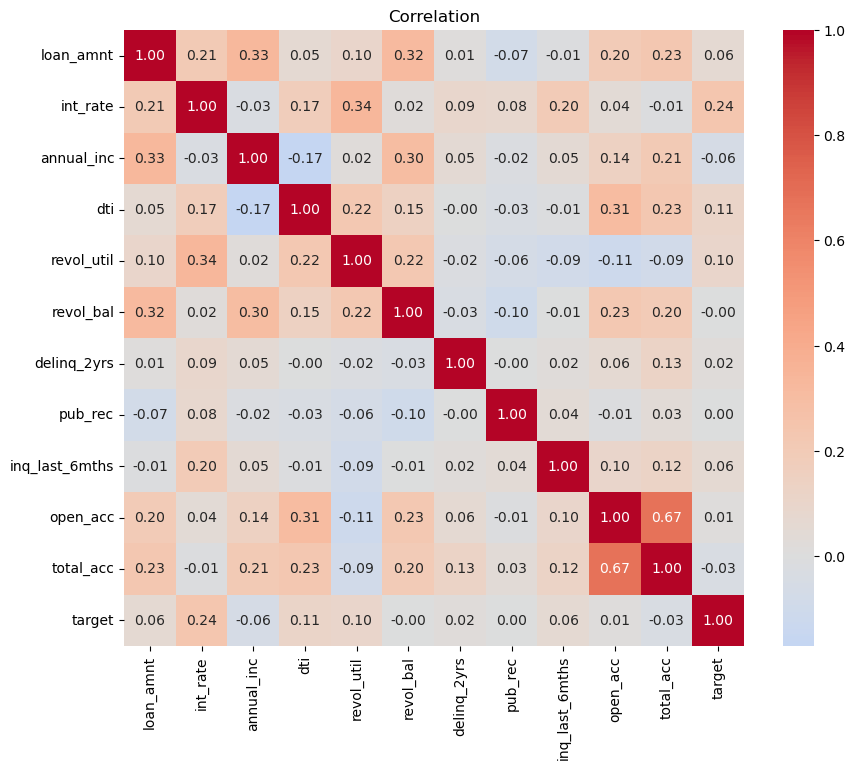

In [6]:
num_vars = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'revol_bal', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'open_acc', 'total_acc']

#Check correlation with the target - compute Pearson correlation matrix
correlations = cm[num_vars + ['target']].corr()['target'].drop('target')
print(correlations.sort_values(key=abs, ascending=False))

#Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = cm[num_vars + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation')

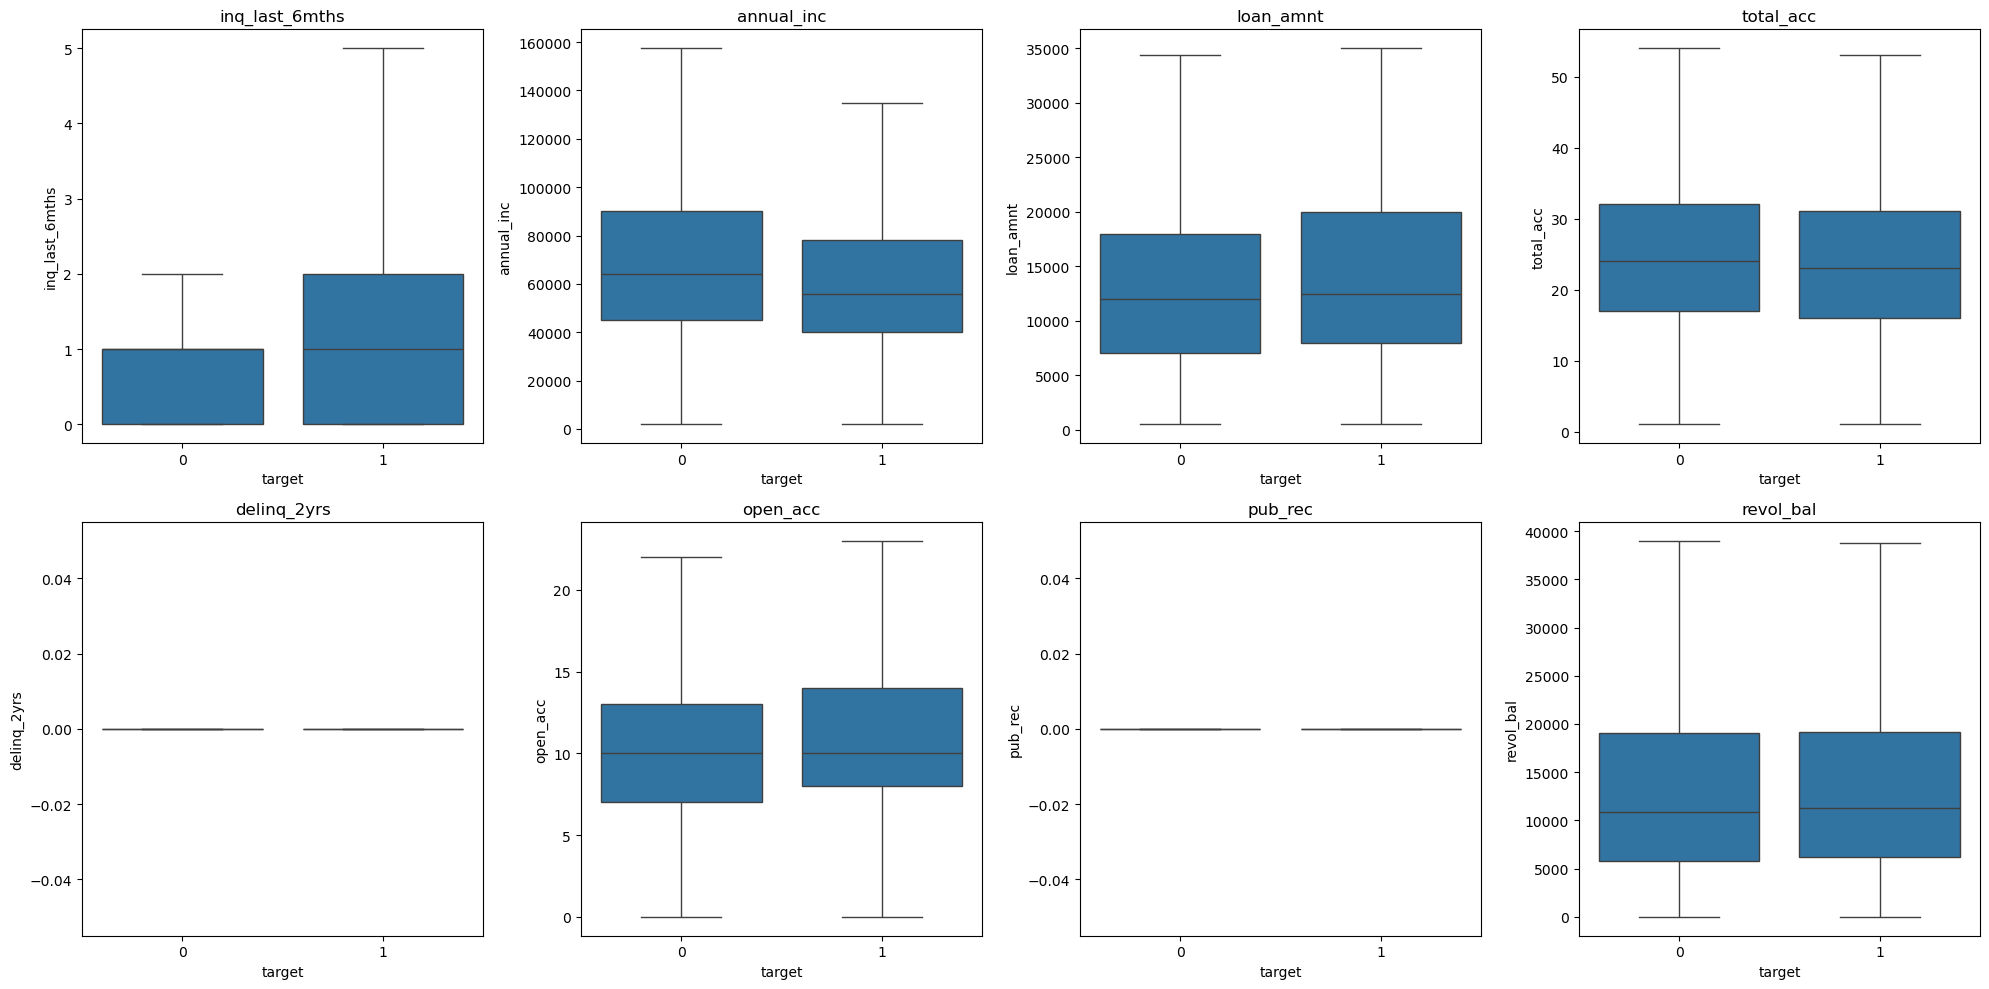

In [7]:
low_corr_vars = ['inq_last_6mths', 'annual_inc', 'loan_amnt', 'total_acc', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(low_corr_vars):
    sns.boxplot(data=cm, x='target', y=col, ax=axes[i], showfliers=False)
    axes[i].set_title(f'{col}')

plt.tight_layout()

We exclude
- **'total_acc'**: no pattern, neither linear nor visual. Plus strong correlation with 'open_acc'
- **'open_acc'**: no clear pattern. Plus strong correlation with 'total_acc'
- **'revol_bal'**: no relevant pattern

For 'delinq_2yrs' and 'pub_rec' we do not deduce enough information from the boxplots. They are highly concentrated at zero, so we use binary indicators.

In [8]:
cm['has_delinq'] = (cm['delinq_2yrs'] > 0).astype(int)
cm['has_pub_rec'] = (cm['pub_rec'] > 0).astype(int)

print(cm.groupby('has_delinq')['target'].mean())
print(cm.groupby('has_pub_rec')['target'].mean())

has_delinq
0    0.181216
1    0.197319
Name: target, dtype: float64
has_pub_rec
0    0.183559
1    0.185611
Name: target, dtype: float64


'has_delinq' shows a small increase in default rate (18.12% -> 19.73%), suggesting some predictive value.
'has_pub_rec' shows almost no difference (18.36% -> 18.56%), suggesting very weak predictive value.
For this reason, we discard 'has_pub_rec'.

In [ ]:
# grade and int_rate are highly redundant (near-monotonic relationship, 
# low within-group variance) -> keep int_rate, drop grade
cm.groupby('grade')['int_rate'].agg(['mean', 'std'])

,mean,std
grade,,
A,7.510585,0.995599
B,11.545822,1.329407
C,14.609879,1.273728
D,17.524906,1.454428
E,20.213548,1.849305
F,23.237456,2.010504
G,24.495511,2.471482


In [28]:
from sklearn.model_selection import train_test_split 

new_categ_vars = [v for v in categ_vars if v != 'grade']

new_num_vars = [v for v in num_vars if v not in ['total_acc', 'open_acc', 'revol_bal', 'delinq_2yrs', 'pub_rec']]
new_num_vars += ['has_delinq']

predictors = new_categ_vars + new_num_vars

#Transform categorical variables in numerical
X = pd.get_dummies(cm[predictors], columns=new_categ_vars, drop_first=True)
Y = cm['target']

# Generate TRAINING e TEST sets
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, stratify=Y)
#stratify to keep the default average proportioned in train and test


## Main evaluation metrics

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score

def PrintEvaluation(y_test, y_pred):
    try:
        print('MAE:', mean_absolute_error(y_test, y_pred))
        print('MSE:', mean_squared_error(y_test, y_pred))
        print('R2:', r2_score(y_test, y_pred))    
        print('ACCURACY:', accuracy_score(y_test, y_pred))
        print('REPORT:',classification_report(y_test, y_pred))
        print('CM:', confusion_matrix(y_test, y_pred))
    except:
        print('Computational error: Debug the code')

## AUC-ROC and Gini metrics

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

def PlotROC(y_test, y_pred_proba, model_name='Model'):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * auc - 1

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f}, Gini = {gini:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.show()

    print(f'AUC: {auc:.4f}')
    print(f'Gini: {gini:.4f}')

In [29]:
#Check NaN values because Logistic Regression does not accept them
print(x_train.isna().sum().sort_values(ascending=False))

revol_util                             185
inq_last_6mths                          19
annual_inc                               3
loan_amnt                                0
emp_length_Missing                       0
emp_length_4 years                       0
emp_length_5 years                       0
emp_length_6 years                       0
emp_length_7 years                       0
emp_length_8 years                       0
emp_length_9 years                       0
emp_length_< 1 year                      0
home_ownership_MORTGAGE                  0
term_ 60 months                          0
emp_length_2 years                       0
home_ownership_NONE                      0
home_ownership_OTHER                     0
home_ownership_OWN                       0
home_ownership_RENT                      0
verification_status_Source Verified      0
emp_length_3 years                       0
purpose_wedding                          0
emp_length_10+ years                     0
purpose_hou

In [30]:
# Handle missing values by replacing them with the median calculated from the training set.
# The same median values are then applied to the test set to avoid data leakage.
w_train = x_train.copy()
w_test = x_test.copy()
for col in new_num_vars:
    median = x_train[col].median()
    w_train[col] = w_train[col].fillna(median)
    w_test[col] = w_test[col].fillna(median)

print(w_train.isna().sum().sort_values(ascending=False))

loan_amnt                              0
emp_length_< 1 year                    0
emp_length_3 years                     0
emp_length_4 years                     0
emp_length_5 years                     0
emp_length_6 years                     0
emp_length_7 years                     0
emp_length_8 years                     0
emp_length_9 years                     0
emp_length_Missing                     0
emp_length_10+ years                   0
term_ 60 months                        0
home_ownership_MORTGAGE                0
home_ownership_NONE                    0
home_ownership_OTHER                   0
home_ownership_OWN                     0
home_ownership_RENT                    0
verification_status_Source Verified    0
emp_length_2 years                     0
purpose_wedding                        0
int_rate                               0
purpose_educational                    0
annual_inc                             0
dti                                    0
revol_util      

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

z_train = w_train.copy()
z_test = w_test.copy()


z_train[new_num_vars] = scaler.fit_transform(z_train[new_num_vars])
z_test[new_num_vars] = scaler.transform(z_test[new_num_vars])

## Logistic Regression

MAE: 0.3477543395345217
MSE: 0.3477543395345217
R2: -1.3179985558919576
ACCURACY: 0.6522456604654783
REPORT:               precision    recall  f1-score   support

           0       0.89      0.65      0.75     52428
           1       0.29      0.64      0.40     11807

    accuracy                           0.65     64235
   macro avg       0.59      0.65      0.58     64235
weighted avg       0.78      0.65      0.69     64235

CM: [[34324 18104]
 [ 4234  7573]]


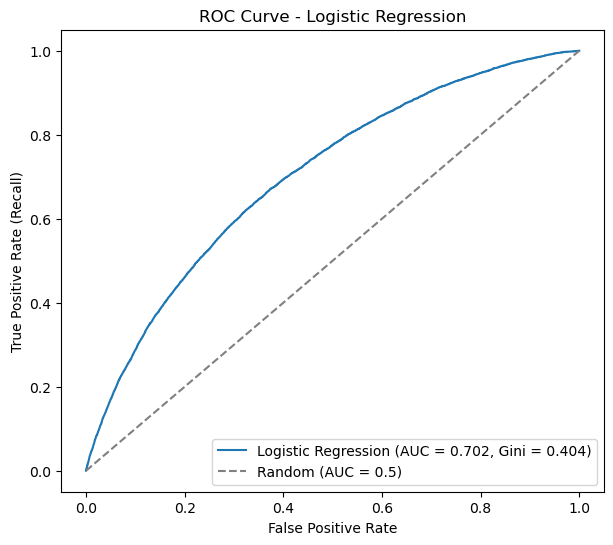

AUC: 0.7022
Gini: 0.4045


In [32]:
from sklearn.linear_model import LogisticRegression

def RunLogisticRegression(x_train, x_test, y_train):
    logit = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=2000) 
    
    logit.fit(x_train, y_train)
    proba = logit.predict_proba(x_test) 
    y_pred_proba = proba[:, 1] #probability of default
    y_pred = [1 if p[0] < p[1] else 0 for p in proba]
    
    return y_pred, y_pred_proba
    
y_pred, y_pred_proba_lr = RunLogisticRegression(z_train, z_test, y_train)
PrintEvaluation(y_test, y_pred)
PlotROC(y_test, y_pred_proba_lr, model_name='Logistic Regression')

## Nearest Neighbours

Best n: {'n_neighbors': 3}
Best F1: 0.2102686280641216
MAE: 0.22813108118626918
MSE: 0.22813108118626918
R2: -0.5206352779139021
ACCURACY: 0.7718689188137309
REPORT:               precision    recall  f1-score   support

           0       0.83      0.91      0.87     52428
           1       0.29      0.17      0.21     11807

    accuracy                           0.77     64235
   macro avg       0.56      0.54      0.54     64235
weighted avg       0.73      0.77      0.75     64235

CM: [[47595  4833]
 [ 9821  1986]]


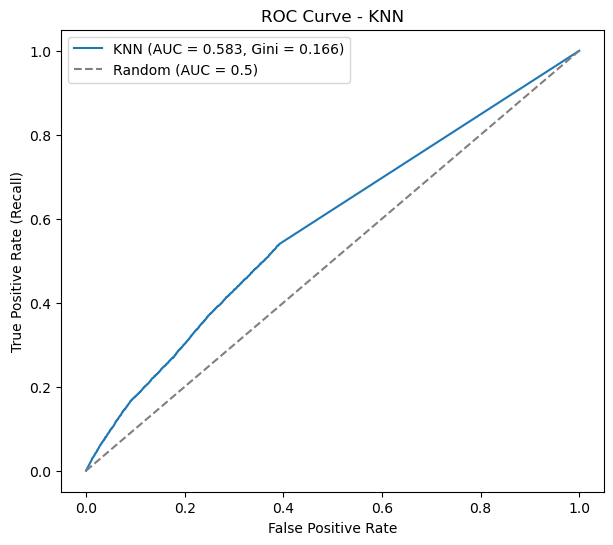

AUC: 0.5829
Gini: 0.1658


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(weights='distance')

params = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]}

grid = GridSearchCV(knn,params,cv=3,scoring='f1', n_jobs=-1)

grid.fit(z_train, y_train)

print('Best n:', grid.best_params_)
print('Best F1:', grid.best_score_)

y_pred = grid.predict(z_test)
y_pred_proba_knn = grid.predict_proba(z_test)[:, 1] #probability of default

PrintEvaluation(y_test, y_pred)
PlotROC(y_test, y_pred_proba_knn, model_name='KNN')

## Gradient Boosting

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 150}
Best F1: 0.4042112438501441
MAE: 0.3611115435510236
MSE: 0.3611115435510236
R2: -1.4070326126989814
ACCURACY: 0.6388884564489764
REPORT:               precision    recall  f1-score   support

           0       0.89      0.63      0.74     52428
           1       0.29      0.66      0.40     11807

    accuracy                           0.64     64235
   macro avg       0.59      0.65      0.57     64235
weighted avg       0.78      0.64      0.68     64235

CM: [[33193 19235]
 [ 3961  7846]]


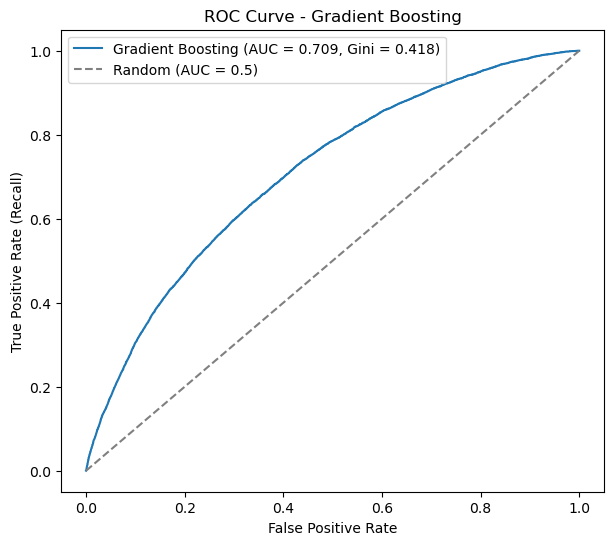

AUC: 0.7089
Gini: 0.4178


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=0, class_weight='balanced')

params = {'max_iter': [100, 150],        #number of decisional trees
          'learning_rate': [0.05, 0.1],
          'max_depth': [2, 3]}            #maximal tree complexity

grid = GridSearchCV(hgb, params, cv=3, scoring='f1', n_jobs=-1)
grid.fit(w_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best F1:', grid.best_score_)

y_pred = grid.predict(w_test)
y_pred_proba_gb = grid.predict_proba(w_test)[:, 1] #probability of default

PrintEvaluation(y_test, y_pred)
PlotROC(y_test, y_pred_proba_gb, model_name='Gradient Boosting')

## Comparing all three models

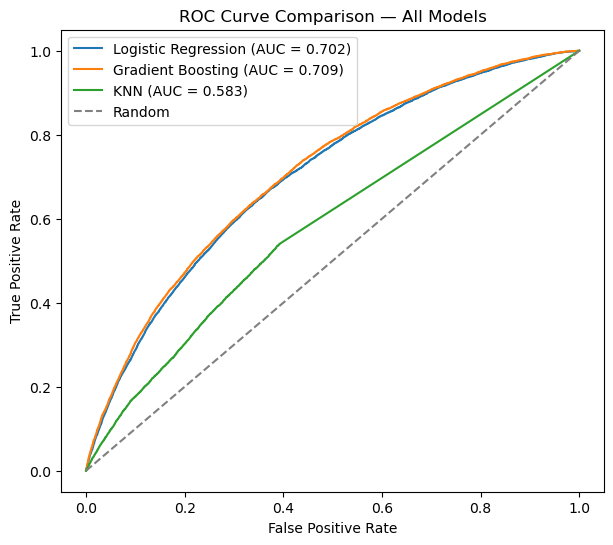

In [36]:
plt.figure(figsize=(7, 6))

models_proba = [
    ('Logistic Regression', y_pred_proba_lr),
    ('Gradient Boosting', y_pred_proba_gb),      
    ('KNN', y_pred_proba_knn)
]

for name, proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.show()

For these classification models, we focus on recall, F1-score, and AUC-ROC (rather than accuracy alone) for the default class, since the dataset is imbalanced and accuracy can be misleading — a model that mostly predicts the 
majority class would still score high on accuracy while failing at the actual goal of identifying defaulters.

Logistic Regression and Gradient Boosting perform nearly identically across every metric (f1-score around 0.40, recall 64-67%, AUC around 0.70), trading lower overall accuracy (64%) for much better detection of defaulters. KNN reaches higher accuracy (77%) but misses around 83% of true defaulters (recall 0.17, 
f1-score 0.21) and has an AUC of only 0.58 — barely above random guessing. This is a clear case of accuracy being misleading on an imbalanced dataset, and the low AUC confirms the issue goes beyond the choice of threshold: KNN, 
unlike the other two models, was not trained with class balancing, leaving it structurally worse at ranking borrowers by risk.

Logistic Regression and Gradient Boosting are therefore the preferable models for this task.